In [1]:
import joblib
import pandas as pd

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV, KFold
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

from xgboost import XGBRegressor

from scipy.stats import randint, uniform
import shap
import cv2
from skimage.feature import hog, local_binary_pattern


import matplotlib.gridspec as gridspec
import matplotlib as mpl


In [3]:
model_dt = joblib.load("best_model_dt_im.joblib")
model_rf = joblib.load("best_model_rf_im.joblib")
model_xgb = joblib.load("best_model_xgb_im.joblib")

model_dt_cl = joblib.load("best_model_dt_im_cl.joblib")
model_rf_cl = joblib.load("best_model_rf_im_cl.joblib")
model_xgb_cl = joblib.load("best_model_xgb_im_cl.joblib")

In [17]:
X_train_cl = pd.read_csv("train_features_cleaned_im.csv").drop(columns = "Unnamed: 0")
X_test_cl = pd.read_csv("test_features_cleaned_im.csv").drop(columns = "Unnamed: 0")


X_train = pd.read_csv("X_train_im_full.csv").drop(columns = "Unnamed: 0")
X_test = pd.read_csv("X_test_im_full.csv").drop(columns = "Unnamed: 0")


print(X_test_cl.shape)
print(X_test.shape)

(3809, 100)
(4181, 100)


In [19]:
X_test_cl.head()

,rgb_62,hog_125,hog_7775,rgb_60,rgb_30,lbp_0,rgb_27,hog_327,hog_547,hog_6998,...,hog_6704,hog_6362,hog_4541,hog_262,hog_2134,hog_4568,hog_1559,rgb_29,hog_7718,hog_7
0,0.000000,0.040097,0.049699,0.016033,0.001363,0.087219,0.148015,0.240763,0.054384,0.023694,...,0.171837,0.222728,0.179005,0.094127,0.258472,0.087977,0.066313,0.010086,0.193749,0.064477
1,0.000000,0.080948,0.000000,0.006586,0.002685,0.101318,0.002110,0.182695,0.052104,0.088249,...,0.022811,0.105877,0.276797,0.251906,0.127243,0.162705,0.097655,0.001343,0.207156,0.049314
2,0.047187,0.528135,0.035215,0.516209,0.058000,0.108154,0.054525,0.026394,0.112752,0.064639,...,0.232615,0.010582,0.066278,0.065457,0.007835,0.033507,0.274598,0.928956,0.045006,0.004136
3,0.020474,0.053097,0.192339,0.062339,0.004556,0.104980,0.037963,0.051562,0.083539,0.095706,...,0.228508,0.205086,0.241505,0.194822,0.247268,0.241505,0.090442,0.008099,0.240722,0.117694
4,0.000000,0.070279,0.000000,0.000000,0.000000,0.083130,0.000000,0.095122,0.162845,0.212453,...,0.033274,0.000000,0.004426,0.020213,0.168518,0.188503,0.211872,0.000000,0.243600,0.098378


In [21]:

def compute_shap_beeswarm(
    model,
    X_train,
    X_test,
    background_size=200,
    random_state=42,
):
    # reproducibility
    np.random.seed(random_state)

    # --- ensure DataFrame (for feature names) ---
    if not isinstance(X_test, pd.DataFrame):
        X_test = pd.DataFrame(X_test)

    if not isinstance(X_train, pd.DataFrame):
        X_train = pd.DataFrame(X_train, columns=X_test.columns)

    feature_names = X_test.columns

    # --- background sample ---
    rng = np.random.default_rng(random_state)
    n_background = min(background_size, X_train.shape[0])
    idx = rng.choice(X_train.shape[0], size=n_background, replace=False)

    X_background = X_train.iloc[idx]

    # --- SHAP ---
    explainer = shap.Explainer(model, X_background)
    shap_values = explainer(X_test, check_additivity=False)

    return shap_values, X_test, feature_names

In [25]:
X_test.shape

(4181, 100)

In [27]:

# --- ORIGINAL DATA ---
shap_dt,  X_dt,  features = compute_shap_beeswarm(model_dt,  X_train, X_test)
shap_rf,  X_rf,  _        = compute_shap_beeswarm(model_rf,  X_train, X_test)
shap_xgb, X_xgb, _        = compute_shap_beeswarm(model_xgb, X_train, X_test)



In [29]:
# --- CLEANED DATA ---
shap_dt_cl,  X_dt_cl,  features_cl = compute_shap_beeswarm(model_dt_cl,  X_train_cl, X_test_cl)
shap_rf_cl,  X_rf_cl,  _           = compute_shap_beeswarm(model_rf_cl,  X_train_cl, X_test_cl)
shap_xgb_cl, X_xgb_cl, _           = compute_shap_beeswarm(model_xgb_cl, X_train_cl, X_test_cl)

100%|===================| 3798/3809 [01:49<00:00]        

In [31]:

shap_original = {
    "Decision Tree": shap_dt,
    "Random Forest": shap_rf,
    "XGBoost": shap_xgb
}


shap_cleaned = {
    "Decision Tree": shap_dt_cl,
    "Random Forest": shap_rf_cl,
    "XGBoost": shap_xgb_cl
}

In [33]:
import pandas as pd
import numpy as np

def shap_to_df(shap_values, feature_names):
    return pd.DataFrame(shap_values.values, columns=feature_names)

def compute_importance(shap_df, top_k=12):
    return shap_df.abs().mean().sort_values(ascending=False).head(top_k)


# --- build storage ---
data = {
    "Decision Tree": shap_dt,
    "Random Forest": shap_rf,
    "XGBoost": shap_xgb
}

results = {}

for name, shap_vals in data.items():
    shap_df = shap_to_df(shap_vals, features)
    importance = compute_importance(shap_df)

    results[name] = {
        "shap_values": shap_vals,
        "shap_df": shap_df,
        "importance": importance
    }

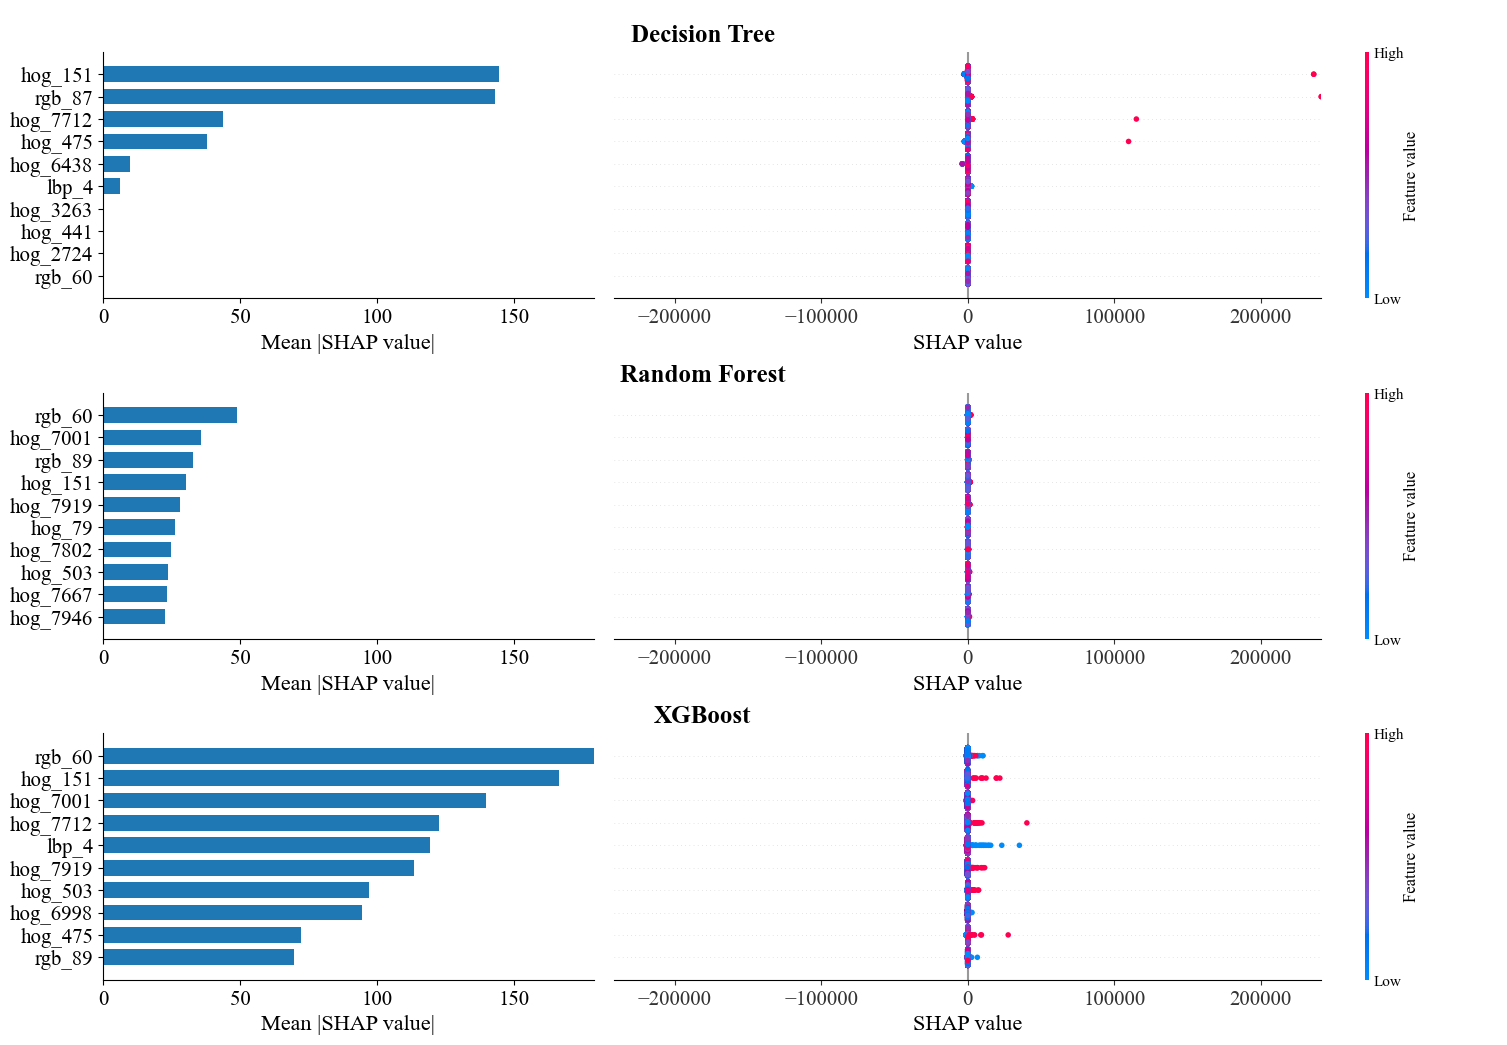

In [37]:

mpl.rcParams["font.family"] = "serif"
mpl.rcParams["font.serif"] = ["Times New Roman"]

TOP_K = 10


TITLE_SIZE = 18
LABEL_SIZE = 16
TICK_SIZE = 15


all_shap_max = []
all_importance_max = []

for res in results.values():
    imp = res["importance"].head(TOP_K)
    shap_vals = res["shap_values"][:, imp.index.tolist()]

    all_importance_max.append(imp.values.max())
    all_shap_max.append(np.abs(shap_vals.values).max())

xmax_importance = max(all_importance_max)
xmax_shap = max(all_shap_max)


n_models = len(results)

fig = plt.figure(figsize=(18, 4.2 * n_models))

outer = gridspec.GridSpec(
    n_models, 1,
    hspace=0.18,
    figure=fig
)


for i, (name, res) in enumerate(results.items()):

    shap_values = res["shap_values"]
    importance = res["importance"].head(TOP_K)


    clean_labels = [f.replace("num_", "").replace("cat_", "").lstrip("_") for f in importance.index]


    top_features = importance.index.tolist()
    shap_values_top = shap_values[:, top_features]


    inner = gridspec.GridSpecFromSubplotSpec(
        2, 2,
        subplot_spec=outer[i],
        height_ratios=[0.16, 1.0],
        width_ratios=[1.0, 1.8],
        hspace=0.02,
        wspace=0.03
    )


    ax_title = fig.add_subplot(inner[0, :])
    ax_title.axis("off")

    ax_title.text(
        0.43, 0.35, name,
        ha="center",
        va="center",
        fontsize=TITLE_SIZE,
        fontweight="bold",
        fontname="Times New Roman",
        transform=ax_title.transAxes
    )


    ax1 = fig.add_subplot(inner[1, 0])

    ax1.barh(
        clean_labels[::-1],             
        importance.values[::-1],
        height=0.7
    )

    ax1.set_xlim(0, xmax_importance)
    ax1.set_xlabel("Mean |SHAP value|", fontsize=LABEL_SIZE)
    ax1.tick_params(axis="both", labelsize=TICK_SIZE)
    ax1.margins(y=0)

    for spine in ["top", "right"]:
        ax1.spines[spine].set_visible(False)

    for label in ax1.get_xticklabels():
        label.set_fontname("Times New Roman")
    for label in ax1.get_yticklabels():
        label.set_fontname("Times New Roman")
    ax1.xaxis.label.set_fontname("Times New Roman")


    ax2 = fig.add_subplot(inner[1, 1])

    shap.plots.beeswarm(
        shap_values_top,
        max_display=TOP_K,
        ax=ax2,
        show=False,
        plot_size=None
    )

    ax2.set_yticklabels([])
    ax2.set_ylabel("")
    ax2.set_xlim(-xmax_shap, xmax_shap)
    ax2.set_xlabel("SHAP value", fontsize=LABEL_SIZE)
    ax2.tick_params(axis="both", labelsize=TICK_SIZE)
    ax2.margins(y=0)

    for label in ax2.get_xticklabels():
        label.set_fontname("Times New Roman")
    for label in ax2.get_yticklabels():
        label.set_fontname("Times New Roman")
    ax2.xaxis.label.set_fontname("Times New Roman")

    ax1.set_ylim(ax2.get_ylim())
    ax2.set_anchor("W")


plt.savefig("shap_comparison_full_IM.png", dpi=300)
plt.show()

In [39]:
results_cleaned = {}

for name, shap_vals in shap_cleaned.items():
    shap_df = pd.DataFrame(shap_vals.values, columns=shap_vals.feature_names)
    importance = shap_df.abs().mean().sort_values(ascending=False).head(12)

    results_cleaned[name] = {
        "shap_values": shap_vals,
        "shap_df": shap_df,
        "importance": importance
    }

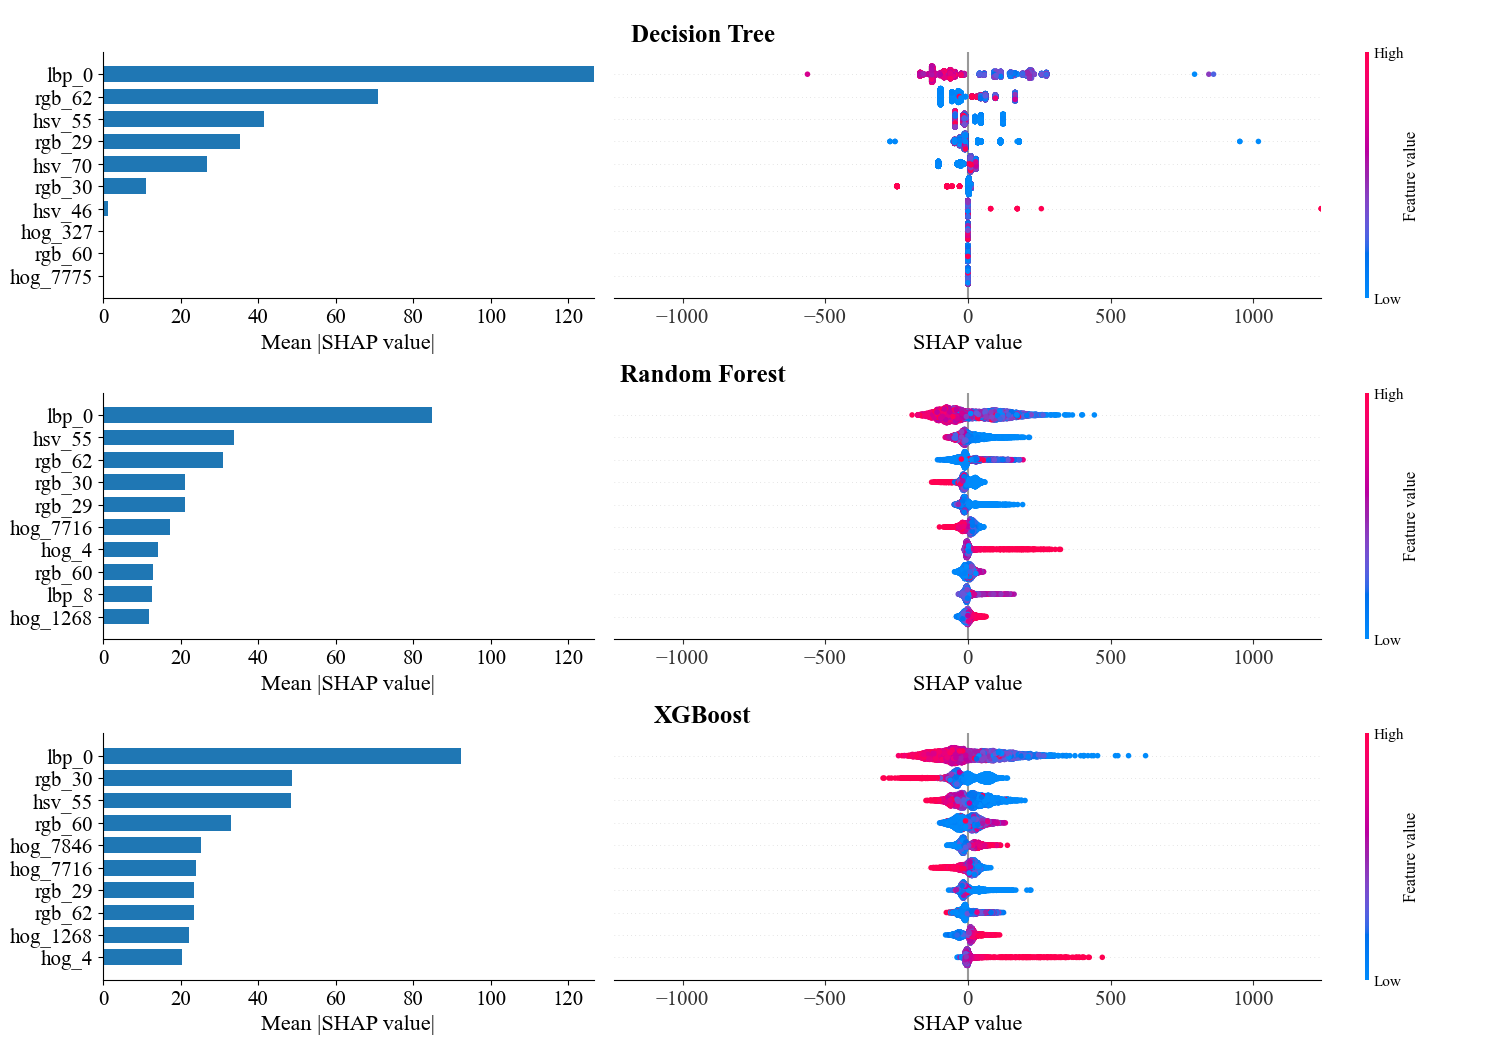

In [41]:


mpl.rcParams["font.family"] = "serif"
mpl.rcParams["font.serif"] = ["Times New Roman"]

TOP_K = 10


TITLE_SIZE = 18
LABEL_SIZE = 16
TICK_SIZE = 15


all_shap_max = []
all_importance_max = []

for res in results_cleaned.values():
    imp = res["importance"].head(TOP_K)
    shap_vals = res["shap_values"][:, imp.index.tolist()]

    all_importance_max.append(imp.values.max())
    all_shap_max.append(np.abs(shap_vals.values).max())

xmax_importance = max(all_importance_max)
xmax_shap = max(all_shap_max)


n_models = len(results_cleaned)

fig = plt.figure(figsize=(18, 4.2 * n_models))

outer = gridspec.GridSpec(
    n_models, 1,
    hspace=0.18,
    figure=fig
)


for i, (name, res) in enumerate(results_cleaned.items()):

    shap_values = res["shap_values"]
    importance = res["importance"].head(TOP_K)


    clean_labels = [
        f.replace("num_", "").replace("cat_", "").lstrip("_")
        for f in importance.index
    ]

    # keep original names for slicing
    top_features = importance.index.tolist()
    shap_values_top = shap_values[:, top_features]


    inner = gridspec.GridSpecFromSubplotSpec(
        2, 2,
        subplot_spec=outer[i],
        height_ratios=[0.16, 1.0],
        width_ratios=[1.0, 1.8],
        hspace=0.02,
        wspace=0.03
    )


    ax_title = fig.add_subplot(inner[0, :])
    ax_title.axis("off")

    ax_title.text(
        0.43, 0.35, name,
        ha="center",
        va="center",
        fontsize=TITLE_SIZE,
        fontweight="bold",
        fontname="Times New Roman",
        transform=ax_title.transAxes
    )


    ax1 = fig.add_subplot(inner[1, 0])

    ax1.barh(
        clean_labels[::-1],   # ✅ cleaned labels used here
        importance.values[::-1],
        height=0.7
    )

    ax1.set_xlim(0, xmax_importance)
    ax1.set_xlabel("Mean |SHAP value|", fontsize=LABEL_SIZE)
    ax1.tick_params(axis="both", labelsize=TICK_SIZE)
    ax1.margins(y=0)

    for spine in ["top", "right"]:
        ax1.spines[spine].set_visible(False)

    for label in ax1.get_xticklabels():
        label.set_fontname("Times New Roman")
    for label in ax1.get_yticklabels():
        label.set_fontname("Times New Roman")
    ax1.xaxis.label.set_fontname("Times New Roman")


    ax2 = fig.add_subplot(inner[1, 1])

    shap.plots.beeswarm(
        shap_values_top,
        max_display=TOP_K,
        ax=ax2,
        show=False,
        plot_size=None
    )

    ax2.set_yticklabels([])
    ax2.set_ylabel("")
    ax2.set_xlim(-xmax_shap, xmax_shap)
    ax2.set_xlabel("SHAP value", fontsize=LABEL_SIZE)
    ax2.tick_params(axis="both", labelsize=TICK_SIZE)
    ax2.margins(y=0)

    for label in ax2.get_xticklabels():
        label.set_fontname("Times New Roman")
    for label in ax2.get_yticklabels():
        label.set_fontname("Times New Roman")
    ax2.xaxis.label.set_fontname("Times New Roman")

    ax1.set_ylim(ax2.get_ylim())
    ax2.set_anchor("W")


plt.savefig("shap_comparison_cleaned_IM.png", dpi=300)
plt.show()